# Rainfall Data End-to-End Project - kajal mahore

In [1]:
from warnings import filterwarnings
filterwarnings('ignore')

### 1.Read the dataset

In [2]:
import pandas as pd
df = pd.read_csv('rainfall.csv')
df.head()

,date,rainfall,temperature,humidity,wind_speed,weather_condition
0,01-01-2022,12.5,15.2,78.0,8.5,Rainy
1,02-01-2022,8.2,17.8,65.0,5.2,Rainy
2,03-01-2022,0.0,20.1,52.0,3.1,Sunny
3,04-01-2022,3.7,18.6,71.0,6.7,Rainy
4,05-01-2022,21.1,14.8,82.0,9.3,Rainy


### 2. Perform basic data quality check

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               54 non-null     str    
 1   rainfall           53 non-null     float64
 2   temperature        53 non-null     float64
 3   humidity           53 non-null     float64
 4   wind_speed         53 non-null     float64
 5   weather_condition  53 non-null     str    
dtypes: float64(4), str(2)
memory usage: 3.4 KB


In [4]:
df.isna().sum()

date                 0
rainfall             1
temperature          1
humidity             1
wind_speed           1
weather_condition    1
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df = df.drop(columns=['date'])
df.head()

,rainfall,temperature,humidity,wind_speed,weather_condition
0,12.5,15.2,78.0,8.5,Rainy
1,8.2,17.8,65.0,5.2,Rainy
2,0.0,20.1,52.0,3.1,Sunny
3,3.7,18.6,71.0,6.7,Rainy
4,21.1,14.8,82.0,9.3,Rainy


In [7]:
df2 = df.dropna(how='any')

In [8]:
df2.head()

,rainfall,temperature,humidity,wind_speed,weather_condition
0,12.5,15.2,78.0,8.5,Rainy
1,8.2,17.8,65.0,5.2,Rainy
2,0.0,20.1,52.0,3.1,Sunny
3,3.7,18.6,71.0,6.7,Rainy
4,21.1,14.8,82.0,9.3,Rainy


In [9]:
df2.isna().sum()

rainfall             0
temperature          0
humidity             0
wind_speed           0
weather_condition    0
dtype: int64

In [10]:
df2['weather_condition'].value_counts()

weather_condition
Rainy    42
Sunny    11
Name: count, dtype: int64

<Axes: xlabel='weather_condition'>

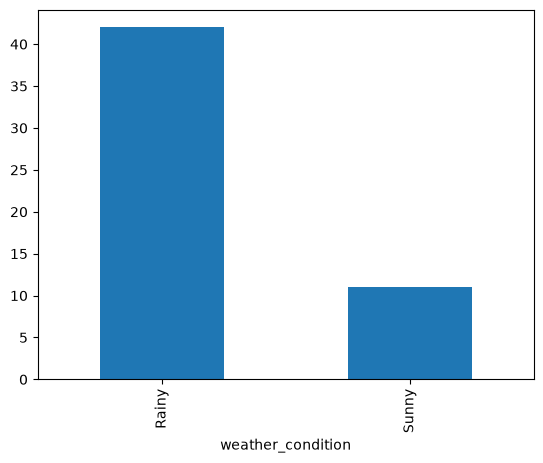

In [11]:
df2['weather_condition'].value_counts().plot(kind='bar')

### 3. Seperate X and Y

In [12]:
X = df2.drop (columns=['weather_condition'])
Y = df2[['weather_condition']]

In [13]:
X.head()

,rainfall,temperature,humidity,wind_speed
0,12.5,15.2,78.0,8.5
1,8.2,17.8,65.0,5.2
2,0.0,20.1,52.0,3.1
3,3.7,18.6,71.0,6.7
4,21.1,14.8,82.0,9.3


In [14]:
Y.head()

,weather_condition
0,Rainy
1,Rainy
2,Sunny
3,Rainy
4,Rainy


### 4. Preprocess the data for X

#### Seperate cat and con features

In [15]:
cat = list(X.columns[X.dtypes=='object'])
con = list(X.columns[X.dtypes!='object'])

In [16]:
cat

[]

In [17]:
con

['rainfall', 'temperature', 'humidity', 'wind_speed']

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [19]:
num_pipe = Pipeline(steps=[('impute', SimpleImputer(strategy='median')),
                           ('scaler', StandardScaler())]).set_output(transform='pandas')  

In [20]:
num_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('impute', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for

In [21]:
X_pre = num_pipe.fit_transform(X)
X_pre.head()

,rainfall,temperature,humidity,wind_speed
0,0.519025,-1.110613,0.738427,0.957999
1,-0.127699,-0.060939,-0.358073,-0.550138
2,-1.360987,0.867619,-1.454573,-1.509862
3,-0.804503,0.262038,0.148004,0.135379
4,1.812474,-1.272101,1.075811,1.323608


### 5. Save the pipeline for future use

In [22]:
import pickle
with open('pipe.pkl', 'wb') as file1:
    pickle.dump(num_pipe,  file1)

### 6. Train test split

In [23]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(X_pre, Y, test_size=0.3, random_state=42)

In [24]:
xtrain.head()

,rainfall,temperature,humidity,wind_speed
37,-0.488661,-0.060939,0.232350,0.226781
24,1.406391,-0.343543,0.569734,0.181080
44,1.722233,-0.949125,0.991465,0.820896
33,0.007662,-1.029869,0.991465,1.140804
49,1.240950,-0.828008,1.160158,1.003700


In [25]:
ytrain.head()

,weather_condition
37,Rainy
24,Rainy
44,Rainy
33,Rainy
49,Rainy


In [26]:
xtest.head()

,rainfall,temperature,humidity,wind_speed
19,1.090549,-1.393217,1.244504,1.232206
41,-1.360987,2.199897,-2.129343,-1.509862
47,-0.593942,-0.222427,0.485388,0.866597
12,-1.360987,1.796176,-2.044996,-1.966873
43,0.864947,-1.635450,1.497542,1.597815


In [27]:
ytest.head()

,weather_condition
19,Rainy
41,Sunny
47,Rainy
12,Sunny
43,Rainy


In [28]:
xtrain.shape

(37, 4)

In [29]:
xtest.shape

(16, 4)

### 7. Create a Random Forest Model

In [30]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(xtrain, ytrain)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

#### Evaluate model in train and test

In [31]:
model.score(xtrain, ytrain)

1.0

In [32]:
model.score(xtest, ytest)

1.0

#### Predict results for train and test

In [33]:
ypred_tr = model.predict(xtrain)
ypred_ts = model.predict(xtest)

In [36]:
ytrain.head()

,weather_condition
37,Rainy
24,Rainy
44,Rainy
33,Rainy
49,Rainy


In [37]:
ypred_tr[0:5]

array(['Rainy', 'Rainy', 'Rainy', 'Rainy', 'Rainy'], dtype=object)

In [38]:
ytest.head()

,weather_condition
19,Rainy
41,Sunny
47,Rainy
12,Sunny
43,Rainy


In [39]:
ypred_ts[0:5]

array(['Rainy', 'Sunny', 'Rainy', 'Sunny', 'Rainy'], dtype=object)

### 8. Plot the confusion matrix for test

In [40]:
model.classes_

array(['Rainy', 'Sunny'], dtype=object)

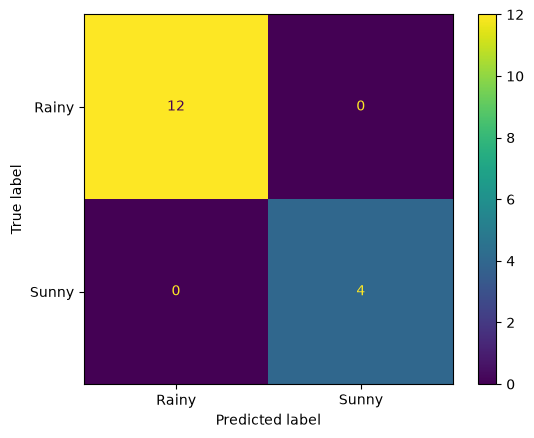

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cf = confusion_matrix(ytest, ypred_ts)
cfd = ConfusionMatrixDisplay(cf, display_labels=model.classes_) 
cfd.plot()

### 9. Print classification report for test

In [44]:
from sklearn.metrics import classification_report
print(classification_report(ytest, ypred_ts))

              precision    recall  f1-score   support

       Rainy       1.00      1.00      1.00        12
       Sunny       1.00      1.00      1.00         4

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



### 10. Cross validate f1 score in training

In [47]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, xtrain, ytrain, cv=5, scoring='f1_macro')
scores

array([1.        , 0.85454545, 1.        , 1.        , 1.        ])

In [48]:
scores.mean()

np.float64(0.9709090909090909)

### Cross validate f1 score >0.8 hence its a good model

### 11. Save the model to use in application

In [50]:
with open('model.pkl', 'wb') as file2:
    pickle.dump(model, file2)
